In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/Social_Network_Ads.csv')

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
(400, 5)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.9125
               precision    recall  f1-score   support

Not Purchased       0.91      0.96      0.93        52
    Purchased       0.92      0.82      0.87        28

     accuracy                           0.91        80
    macro avg       0.91      0.89      0.90        80
 weighted avg       0.91      0.91      0.91        80

Confusion matrix:
 [[50  2]
 [ 5 23]]
[0 1 1]
Age 22: Purchased = 0  (probability of Yes = 0.03)
Age 45: Purchased = 1  (probability of Yes = 0.59)
Age 63: Purchased = 1  (probability of Yes = 0.97)

Saved plot -> binary_logistic_plot.png


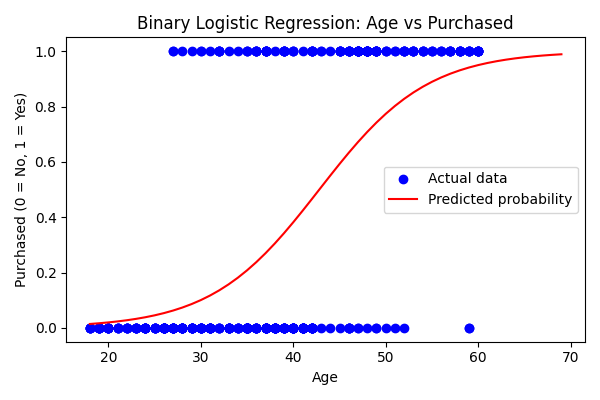

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 1: Load the data
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/colab/Social_Network_Ads.csv")
print(df.head())
print(df.shape)


# ===========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Feature: Age   ->   Target: Purchased (0 = No, 1 = Yes)
# ===========================================================
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[["Age"]]              # feature must be 2D -> double brackets
y = df["Purchased"]          # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Not Purchased", "Purchased"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Predict for a new person
new_age = pd.DataFrame({"Age": [22, 45, 63]})
predictions = binary_model.predict(new_age)
print(predictions)
probabilities = binary_model.predict_proba(new_age)[:, 1]   # probability of "Yes"
for age_val, pred, prob in zip(new_age["Age"], predictions, probabilities):
    print(f"Age {age_val}: Purchased = {pred}  (probability of Yes = {prob:.2f})")

# Simple plot: Age vs Purchased with the model's S-curve
plt.figure(figsize=(6, 4))
plt.scatter(df["Age"], df["Purchased"], color="blue", label="Actual data")
age_range = pd.DataFrame({"Age": range(18, 70)})
plt.plot(age_range["Age"], binary_model.predict_proba(age_range)[:, 1],
         color="red", label="Predicted probability")
plt.xlabel("Age")
plt.ylabel("Purchased (0 = No, 1 = Yes)")
plt.title("Binary Logistic Regression: Age vs Purchased")
plt.legend()
plt.tight_layout()
plt.savefig("binary_logistic_plot.png")
print("\nSaved plot -> binary_logistic_plot.png")
